机器翻译是将一种语言的序列自动转换为另一种语言的任务，本质上属于序列到序列（Seq2Seq）建模问题，即学习从输入序列
(
𝑥
1
,
…
,
𝑥
𝑇
)
到输出序列
(
𝑦
1
,
…
,
𝑦
𝑇
′
)
的映射关系。它是自然语言处理中最重要的应用之一，也是检验序列模型能力的经典任务。

早期方法主要是统计机器翻译（SMT），依赖翻译模型和语言模型的组合；而现代方法则是神经机器翻译（NMT），使用神经网络进行端到端学习，直接建模条件概率
𝑃
(
𝑦
1
,
…
,
𝑦
𝑇
′
∣
𝑥
1
,
…
,
𝑥
𝑇
)
，显著提升了效果。

与语言模型不同，机器翻译的数据集由**双语句子对（parallel corpus）**组成，即每个样本包含“源语言序列”和“目标语言序列”。因此，其数据预处理也更加复杂，需要分别构建词表、处理不同长度序列，并设计适合序列映射的输入输出结构。

In [1]:
import os
import torch

下载和预处理数据集

下载一个由Tatoeba项目的双语句子对 组成的“英－法”数据集，数据集中的每一行都是制表符分隔的文本序列对， 序列对由英文文本序列和翻译后的法语文本序列组成。



In [3]:
import requests
import zipfile
import os


url = "http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip"
zip_path = "fra-eng.zip"
extract_dir = "fra-eng"

# 下载
response = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(response.content)

# 解压
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


def read_data_nmt():
    file_path = os.path.join(extract_dir, "fra-eng", "fra.txt")
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()

raw_text = read_data_nmt()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



将原始文本数据预处理

空格代替不间断空格（non-breaking space）， 使用小写字母替换大写字母，并在单词和标点符号之间插入空格。

In [4]:
def preprocess_nmt(text):
    """预处理“英语－法语”数据集"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    # 使用空格替换不间断空格
    # 使用小写字母替换大写字母
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在单词和标点符号之间插入空格
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

text = preprocess_nmt(raw_text)
print(text[:80])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


词元化

与语言模型的字符级词元化不同，在机器翻译中，我们更喜欢单词级词元化。
下面的tokenize_nmt函数对前num_examples个文本序列对进行词元， 其中每个词元要么是一个词，要么是一个标点符号。




In [5]:
def tokenize_nmt(text, num_examples=None):
    """词元化“英语－法语”数据数据集"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

source, target = tokenize_nmt(text)
source[:6], target[:6]

([['go', '.'],
  ['hi', '.'],
  ['run', '!'],
  ['run', '!'],
  ['who', '?'],
  ['wow', '!']],
 [['va', '!'],
  ['salut', '!'],
  ['cours', '!'],
  ['courez', '!'],
  ['qui', '?'],
  ['ça', 'alors', '!']])

绘制每个文本序列所包含的词元数量的直方图

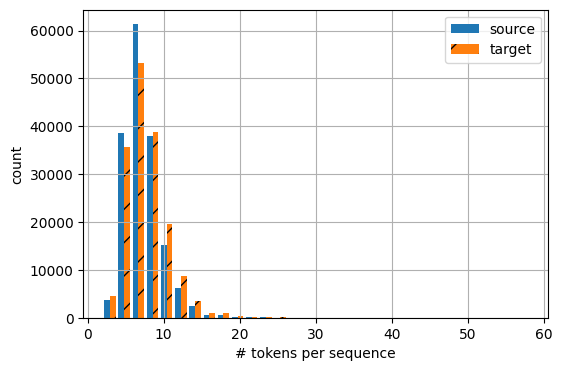

In [6]:
import matplotlib.pyplot as plt

def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """绘制列表长度对的直方图"""

    x_len = [len(l) for l in xlist]
    y_len = [len(l) for l in ylist]

    plt.figure(figsize=(6, 4))

    # 两组数据一起画
    n, bins, patches = plt.hist(
        [x_len, y_len],
        bins=30,
        label=legend
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # 给第二组加斜线（模仿 d2l 效果）
    for patch in patches[1]:
        patch.set_hatch('/')

    plt.legend()
    plt.grid()
    plt.show()


# 调用
show_list_len_pair_hist(
    ['source', 'target'],
    '# tokens per sequence',
    'count',
    source,
    target
)

词表

由于机器翻译数据集由语言对组成， 因此我们可以分别为源语言和目标语言构建两个词表。 使用单词级词元化时，词表大小将明显大于使用字符级词元化时的词表大小。

为了缓解这一问题，这里我们将出现次数少于2次的低频率词元 视为相同的未知（“<unk>”）词元。 除此之外，我们还指定了额外的特定词元

In [20]:
from collections import Counter

class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=None):
        from collections import Counter

        if reserved_tokens is None:
            reserved_tokens = []

        tokens = [token for line in tokens for token in line]
        counter = Counter(tokens)

        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        for token, freq in counter.items():
            if freq >= min_freq and token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if isinstance(tokens, (list, tuple)):
            return [self.__getitem__(token) for token in tokens]
        return self.token_to_idx.get(tokens, self.token_to_idx['<unk>'])

    def to_tokens(self, indices):
        if isinstance(indices, (list, tuple)):
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[int(indices)]

In [21]:
src_vocab = Vocab(source, min_freq=2,
                      reserved_tokens=['<pad>', '<bos>', '<eos>'])
len(src_vocab)

10012

加载数据集

语言模型中序列样本都有一个固定的长度，由时间步数或词元数量参数指定。在机器翻译中，每个样本都是由源和目标组成的文本序列对， 其中的每个文本序列可能具有不同的长度。

为了提高计算效率，我们仍然可以通过截断（truncation）和 填充（padding）方式实现一次只处理一个小批量的文本序列。

在小批量的序列中，少于num_steps，将继续在其末尾添加特定的“pad”词元。反之，我们将截断文本序列时，只取其前num_steps 个词元， 并且丢弃剩余的词元。

通过下面函数实现

In [22]:
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

line = [src_vocab[token] for token in source[0]]
print(line)
print(truncate_pad(line, 10, src_vocab['<pad>']))

[4, 5]
[4, 5, 1, 1, 1, 1, 1, 1, 1, 1]


定义函数将文本序列转换成小批量数据集用于训练

eos词元添加到所有序列的末尾， 用于表示序列的结束。

In [23]:
def build_array_nmt(lines, vocab, num_steps):
    lines = [vocab[l] + [vocab['<eos>']] for l in lines]
    array = torch.tensor(
        [truncate_pad(l, num_steps, vocab['<pad>']) for l in lines],
        dtype=torch.long
    )
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

训练模型

In [24]:
def load_data_nmt(batch_size, num_steps, num_examples=600):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)

    src_vocab = Vocab(source, min_freq=2,
                      reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,
                      reserved_tokens=['<pad>', '<bos>', '<eos>'])

    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)

    dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)
    train_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return train_iter, src_vocab, tgt_vocab

读出“英语－法语”数据集中的第一个小批量数据

In [26]:
from torch.utils.data import TensorDataset, DataLoader
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)
for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X:', X.type(torch.int32))
    print('X的有效长度:', X_valid_len)
    print('Y:', Y.type(torch.int32))
    print('Y的有效长度:', Y_valid_len)
    break

X: tensor([[105, 179,   5,   3,   1,   1,   1,   1],
        [ 23,   8,   3,   1,   1,   1,   1,   1]], dtype=torch.int32)
X的有效长度: tensor([4, 3])
Y: tensor([[ 0, 50, 11,  5,  3,  1,  1,  1],
        [ 0,  5,  3,  1,  1,  1,  1,  1]], dtype=torch.int32)
Y的有效长度: tensor([5, 3])
